In [1]:
import math
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [3]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [4]:
def get_contamination_fraction(zoom, xmatch):

    # The high-resolution mass will be sum of the DM, gas, stars and BH mass
    hd_mass = (zoom.fof['halo_mfof_type'][:,0] + zoom.fof['halo_mfof_type'][:,1] + zoom.fof['halo_mfof_type'][:,4] + zoom.fof['halo_mfof_type'][:,5])[xmatch['ind']]

    # The low resolution mass will be the sum of the low-res DM particles
    lr_mass = zoom.fof['halo_mfof_type'][:,2][xmatch['ind']] + zoom.fof['halo_mfof_type'][:,3][xmatch['ind']]

    return lr_mass / (hd_mass + lr_mass)   

In [6]:
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264

In [7]:
# Load Lite snapshot of the MTNG
snap = 264
numpart = int(4320**3/64)

adr = "/cosmos_storage/simulations/TNG_Family/MTNG/"

sim_format = 'TNG500'
mtng = bacco.Simulation(verbose=False,basedir=adr, halo_file='groups_%03d/fof_subhalo_tab_%03d'%(snap,snap),\
                        dm_file='64/lite_snap_%03d_mod/diluted_snapshot_%03d'%(snap,snap),\
                        tau=tau, ns=ns, sigma8=sigma8, numpart=numpart, sim_format=sim_format,\
                        use_orphans=False, total_snapshots=265, use_ids=False)
                        
hydro_split = utils.split_halos(mtng)
hydro_split.halo_sel_setup()

Nbins = 20
smf_total = hydro_split.total_smf_30kpc(nbins=Nbins, red_fac=64)

2026-06-25 03:31:54,163 bacco.sims : Initialising simulation Default
2026-06-25 03:31:54,164 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/64/lite_snap_264_mod/diluted_snapshot_264
2026-06-25 03:31:54,233 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/64/lite_snap_264_mod/diluted_snapshot_264
2026-06-25 03:31:54,291 bacco.sims : ...done in 0.128 s
2026-06-25 03:31:54,335 bacco.sims : Reading 98233510 items for Group_M_Mean200


2026-06-25 03:32:46,288 bacco.sims : Reading 90246895 items for SubhaloVmax
2026-06-25 03:33:42,650 bacco.sims : Reading 98233510 items for halo_firstsub
2026-06-25 03:34:18,632 bacco.sims : Read data for 86309/55956315 particles...
2026-06-25 03:34:18,748 bacco.sims : Read data for 86309/55956315 particles...
2026-06-25 03:34:18,813 bacco.sims : Read data for 89647/55956315 particles...


/cosmos_storage/simulations/TNG_Family/MTNG/64/lite_snap_264_mod/diluted_snapshot_264.0.hdf5


2026-06-25 03:34:18,903 bacco.sims : Read data for 89647/55956315 particles...
2026-06-25 03:34:18,971 bacco.sims : Read data for 86192/55956315 particles...
2026-06-25 03:34:19,065 bacco.sims : Read data for 86192/55956315 particles...
2026-06-25 03:34:19,112 bacco.sims : Read data for 89031/55956315 particles...
2026-06-25 03:34:19,202 bacco.sims : Read data for 89031/55956315 particles...
2026-06-25 03:34:19,262 bacco.sims : Read data for 86780/55956315 particles...
2026-06-25 03:34:19,364 bacco.sims : Read data for 86780/55956315 particles...
2026-06-25 03:34:19,438 bacco.sims : Read data for 88058/55956315 particles...
2026-06-25 03:34:19,531 bacco.sims : Read data for 88058/55956315 particles...
2026-06-25 03:34:19,593 bacco.sims : Read data for 85021/55956315 particles...
2026-06-25 03:34:19,687 bacco.sims : Read data for 85021/55956315 particles...
2026-06-25 03:34:19,752 bacco.sims : Read data for 87416/55956315 particles...
2026-06-25 03:34:19,846 bacco.sims : Read data for 8

In [8]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                    tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2026-06-25 03:55:00,802 bacco.sims : Initialising simulation Default
2026-06-25 03:55:00,802 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-25 03:55:00,867 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-25 03:55:00,882 bacco.sims : ...done in 0.0804 s


In [14]:
def get_smf_local(thr=0.01, Nbins=20):
    # thr = 0.01
    # Nbins = 20

    cont_cut = f_cont < thr

    # Load the Halo Selection
    with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
        final_sel = []
        for line in f.readlines():
            final_sel.append(int(line.split()[0]))

    orig_sel = np.copy(np.array(final_sel))
    final_sel = np.array(final_sel)[cont_cut]

    m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

    mbins = np.concatenate(
        (np.arange(11, 11.5, 0.0025),
        np.arange(11.5, 12.5, 0.005),
        np.arange(12.5, 13.5, 0.025),
        np.arange(13.5, 15.01, 0.125))
    )

    ind_mtng = np.digitize(m200b, bins=mbins)
    clean = (ind_mtng != len(mbins))

    ind_sel = np.digitize(m200b[orig_sel], bins=mbins)

    h_frac = np.bincount(ind_sel)[1:] / np.bincount(ind_mtng[clean])[1:]

    zoom_split = utils.split_halos(zoom)

    zoom_sel = {}
    zoom_sel['sel'] = xmatch['ind'][cont_cut,np.newaxis,np.newaxis]
    zoom_sel['h_frac'] = h_frac[np.newaxis, cont_cut]

    zoom_smf = zoom_split.halo_smf_draws(sel_mask=zoom_sel, nbins=Nbins, draws=1, m_30kpc=True)

    return zoom_smf, zoom_sel

sel_mask = zoom_sel
nbins = Nbins
draws = 1
# m_30kpc = False

In [15]:
bins = np.logspace(9, 12.5, nbins)
counts     = {d:np.zeros(nbins-1) for d in range(draws)}
hist       = {d:np.zeros(nbins-1) for d in range(draws)}
mstar_mean = {d:np.zeros(nbins-1) for d in range(draws)}

first = zoom.fof['halo_firstsub']#[presel]
nsubs = zoom.fof['halo_nsubs']#[presel]

for m in range(len(sel_mask['sel'])):
    for d in range(draws):
        if sel_mask['h_frac'][d][m]!=0:
            mstar = []
            for i in range(len(sel_mask['sel'][m][d])):
                if m_30kpc is True:
                    sub_indices = np.arange(first[sel_mask['sel'][m][d][i]],first[sel_mask['sel'][m][d][i]]+nsubs[sel_mask['sel'][m][d][i]])
                    mstar_ = self.get_mstar_30kpc_vec( sub_indices )
                    mstar.extend( mstar_ )
                else:
                    mstar.extend(zoom.sub['MassType'][:,4][first[sel_mask['sel'][m][d][i]]:first[sel_mask['sel'][m][d][i]]+nsubs[sel_mask['sel'][m][d][i]]] / zoom.Cosmology.pars['hubble'])
            
            mstar = 1e10 * np.array(mstar)

            ids = np.digitize(mstar, bins)
            counts_i = [np.sum( np.ones(len(mstar))[np.where(ids==j)]) for j in range(1,len(bins))]  / sel_mask['h_frac'][d][m]

            counts[d] += counts_i
            hist[d]   += np.array(counts_i)
            mstar_mean[d] += [np.sum(mstar[np.where(ids==j)]) for j in range(1,len(bins))] / sel_mask['h_frac'][d][m]

bin_width = np.log10(bins[1:])-np.log10(bins[:-1])
norm = 1 / ( ( zoom.header['BoxSize'] / zoom.Cosmology.pars['hubble'] )**3 * bin_width )

for d in range(draws):
    hist[d] *= norm
    mstar_mean[d] = mstar_mean[d] / counts[d]


2026-06-25 04:00:19,432 bacco.sims : Reading 139956 items for halo_firstsub


2026-06-25 04:00:19,831 bacco.sims : Reading 139956 items for GroupNsubs


NameError: name 'sel_mask' is not defined

In [17]:
### Load the Halo Selection ###
xmatch = utils.cross_match(zoom, snap=264, name='fiducial')

In [18]:
f_cont = get_contamination_fraction(zoom, xmatch)

2026-06-25 04:00:54,634 bacco.sims : Reading 139956 items for GroupMassType


In [19]:
zoom_smf_strict, zoom_sel_strict = get_smf_local(thr=0.001, Nbins=Nbins)
zoom_smf, zoom_sel = get_smf_local(thr=0.01, Nbins=Nbins)
zoom_smf_total, zoom_sel_total = get_smf_local(thr=1, Nbins=Nbins)

/tmp/ipykernel_166665/3968048770.py:16: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])
2026-06-25 04:01:00,409 bacco.sims : Reading 74777 items for Subhalo/SubhaloOffset
2026-06-25 04:01:00,543 bacco.sims : Reading 74777 items for SubhaloLenType
2026-06-25 04:01:00,667 bacco.sims : Read data for 796017/6141061 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-06-25 04:01:01,078 bacco.sims : Read data for 796017/6141061 particles...
2026-06-25 04:01:01,089 bacco.sims : Read data for 742440/6141061 particles...
2026-06-25 04:01:01,516 bacco.sims : Read data for 742440/6141061 particles...
2026-06-25 04:01:01,558 bacco.sims : Read data for 770918/6141061 particles...
2026-06-25 04:01:01,985 bacco.sims : Read data for 770918/6141061 particles...
2026-06-25 04:01:02,004 bacco.sims : Read data for 792109/6141061 particles...
2026-06-25 04:01:02,442 bacco.sims : Read data for 792109/6141061 particles...
2026-06-25 04:01:02,504 bacco.sims : Read data for 736460/6141061 particles...
2026-06-25 04:01:02,953 bacco.sims : Read data for 736460/6141061 particles...
2026-06-25 04:01:02,986 bacco.sims : Read data for 757977/6141061 particles...
2026-06-25 04:01:03,376 bacco.sims : Read data for 757977/6141061 particles...
2026-06-25 04:01:03,407 bacco.sims : Read data for 779883/6141061 particles...
2026-06-25 04:01:03,845 bacco.sims : Read data for 7

/tmp/ipykernel_166665/1875484364.py:12: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(smf_total['mstar']), np.log10(smf_total['smf']), color='k')


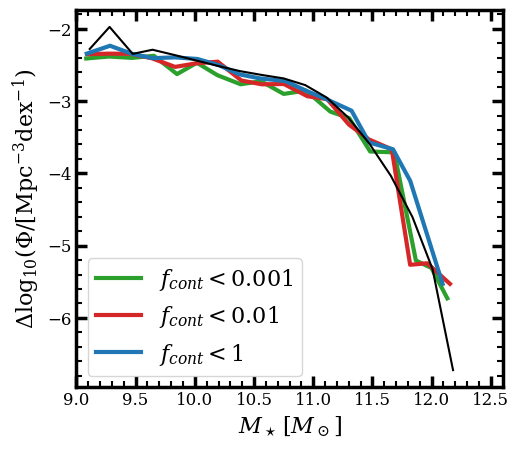

In [20]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5), dpi=100)

ax.set_xlim(8,12.5)

ax.set_xscale('linear')
ax.set_yscale('linear')

ax.plot(np.log10(zoom_smf_strict['mstar'][0]), np.log10(zoom_smf_strict['smf'][0]), color="C2", lw=3, label='$f_{cont} < 0.001$')
ax.plot(np.log10(zoom_smf['mstar'][0]), np.log10(zoom_smf['smf'][0]), color="C3", lw=3, label='$f_{cont} < 0.01$')
ax.plot(np.log10(zoom_smf_total['mstar'][0]), np.log10(zoom_smf_total['smf'][0]), color="C0", lw=3, label='$f_{cont} < 1$')
# ax.plot(np.log10(mtng_smf[::2,0]), np.log10(mtng_smf[::2,1]), color="k", lw=3, label='MTNG')
ax.plot(np.log10(smf_total['mstar']), np.log10(smf_total['smf']), color='k')

ax.legend(fontsize=16)

ax.set_xlim(9,12.6)
# ax.set_ylim(-0.5,0.5)
ax.set_xlabel(r"$M_\star\, [M_\odot]$", fontsize=16)
ax.set_ylabel(r"$\Delta \log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1})$", fontsize=16)

# ax.axhline(0, color="k", ls="--", lw=3)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Major and minor ticks
ax.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, direction='in', top=True, right=True)
ax.tick_params(axis='both', which='minor', width=1.5, length=4, direction='in', top=True, right=True)
ax.minorticks_on()

In [26]:
def mean_std_without_zeros(array):
    ndraws, nbins = array.shape
    mean_values = []
    std_values = []

    for i in range(nbins):
        non_zero_values = array[:, i][array[:, i] != 0]
        mean_values.append(np.mean(non_zero_values))
        std_values.append(np.std(non_zero_values))

    return np.array(mean_values), np.array(std_values)


smf_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_draws/smf_draws100_nbins10.npy", allow_pickle=True).item()

mean_smf_nz, err_smf_nz = mean_std_without_zeros(smf_draws['ens_smf'])
err_log_smf = err_smf_nz / mean_smf_nz / np.log(10)
mstar_mean, _ = mean_std_without_zeros(smf_draws['mstar'])

/tmp/ipykernel_95020/1715670523.py:12: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(smf_total['mstar']), np.log10(smf_total['smf']), color='k', lw=3)
/tmp/ipykernel_95020/1715670523.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


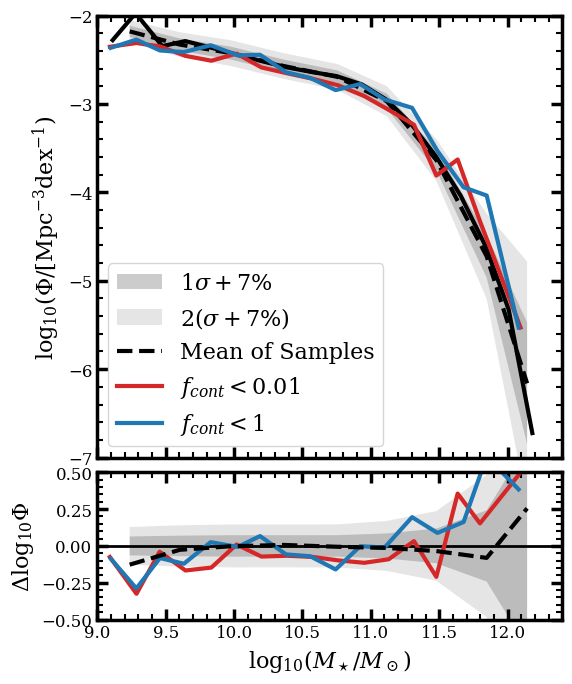

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with two subplots, sharing the x-axis
# height_ratios=[3, 1] makes the top plot 3 times taller than the bottom one
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 8), dpi=100, sharex=True, 
                                 gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Main Plot (Top) ---
ax.fill_between(np.log10(mstar_mean), np.log10(mean_smf_nz) - (err_log_smf+err_7_pc), np.log10(mean_smf_nz) + (err_log_smf+err_7_pc), color='gray', alpha=0.4, edgecolor=None, label='1$\sigma+7\%$')
ax.fill_between(np.log10(mstar_mean), np.log10(mean_smf_nz) - 2 * (err_log_smf+err_7_pc), np.log10(mean_smf_nz) + 2 * (err_log_smf+err_7_pc), color='gray', alpha=0.2, edgecolor=None, label='2$(\sigma+7\%)$')
ax.plot(np.log10(smf_total['mstar']), np.log10(smf_total['smf']), color='k', lw=3)
ax.plot(np.log10(mstar_mean), np.log10(mean_smf_nz), color='k', ls='--', lw=3, label='Mean of Samples')


ax.plot(np.log10(zoom_smf['mstar'][0]), np.log10(zoom_smf['smf'][0]), 
        color="C3", lw=3, label='$f_{cont} < 0.01$')
ax.plot(np.log10(zoom_smf_total['mstar'][0]), np.log10(zoom_smf_total['smf'][0]), 
        color="C0", lw=3, label='$f_{cont} < 1$')

ax.legend(fontsize=16, loc='lower left')
ax.set_ylabel(r"$\log_{10}(\Phi/[$Mpc$^{-3}$dex$^{-1})$", fontsize=16)

# --- Residual Plot (Bottom) ---
# Calculate residues
res_zoom = np.log10(zoom_smf['smf'][0]) - np.interp(np.log10(zoom_smf['mstar'][0]), 
                                                   np.log10(smf_total['mstar'][:-1]), 
                                                   np.log10(smf_total['smf'][:-1]))
res_total = np.log10(zoom_smf_total['smf'][0]) - np.interp(np.log10(zoom_smf_total['mstar'][0]), 
                                                          np.log10(smf_total['mstar'][:-1]), 
                                                          np.log10(smf_total['smf'][:-1]))

res_mean = np.log10(mean_smf_nz) - np.interp(np.log10(mstar_mean), np.log10(smf_total['mstar'][:-1]), np.log10(smf_total['smf'][:-1]))

ax_res.axhline(0, color="k", ls="-", lw=2)

ax_res.plot(np.log10(zoom_smf['mstar'][0]), res_zoom, color="C3", lw=3)
ax_res.plot(np.log10(zoom_smf_total['mstar'][0]), res_total, color="C0", lw=3)
ax_res.plot(np.log10(mstar_mean), res_mean, color='k', ls='--', lw=3)

err_7_pc = 0.07 / np.log(10) # Convert 7% error in linear space to log space

ax_res.fill_between(np.log10(mstar_mean), - (err_log_smf+err_7_pc), (err_log_smf+err_7_pc), color='gray', alpha=0.4, edgecolor=None)
ax_res.fill_between(np.log10(mstar_mean), - 2 * (err_log_smf+err_7_pc), 2 * (err_log_smf+err_7_pc), color='gray', alpha=0.2, edgecolor=None)
# ax_res.fill_between(np.linspace(8, 13, 100), -0.2, 0.2, color="gray", alpha=0.2, ec=None)
# ax_res.fill_between(np.linspace(8, 13, 100), -0.1, 0.1, color="gray", alpha=0.3, ec=None)

ax_res.set_ylim(-0.5, 0.5)
ax_res.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$", fontsize=16)
ax_res.set_ylabel(r"$\Delta \log_{10} \Phi$", fontsize=16)

# --- Global Formatting ---
ax.set_xlim(9, 12.4)
ax.set_ylim(-7,-2)

for a in [ax, ax_res]:
    for spine in a.spines.values():
        spine.set_linewidth(2.5)
    
    # Major and minor ticks
    a.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, 
                  direction='in', top=True, right=True)
    a.tick_params(axis='both', which='minor', width=1.5, length=4, 
                  direction='in', top=True, right=True)
    a.minorticks_on()

# Remove x-axis tick labels from the top plot to avoid overlap
plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/validation/smf_contamination_comparison.pdf", bbox_inches='tight')
plt.show()

### Now I have to do the same for the gas-fractions

In [30]:
import numpy as np

mtng_gas_frac = np.array([
    [130609919929.12088, 0.04094802680868123],
    [143610941351.11203, 0.04253487189621874],
    [160234552273.0856, 0.04469494196100218],
    [177378493973.7467, 0.04658944165746767],
    [196454047675.97766, 0.04801041194207645],
    [215907732620.99667, 0.04977275680950086],
    [238287594536.3316, 0.05164524182264041],
    [262661616593.0652, 0.0535387726830312],
    [289041084875.91144, 0.05534032935198607],
    [317583839983.3964, 0.057456799315350526],
    [357626252907.0332, 0.059386369351380475],
    [392631028749.43713, 0.06115055586607013],
    [438212728330.6139, 0.06292607476746209],
    [487774316556.6669, 0.06502439998858639],
    [542539713351.9781, 0.06649121823708734],
    [603433152670.6445, 0.06773211749425102],
    [671155749481.7175, 0.06892043101094429],
    [746480853751.2206, 0.07012700214458209],
    [830222859929.5281, 0.07104167328786928],
    [923240130549.5294, 0.07111088363816882],
    [1026673667006.761, 0.0711463364154721],
    [1141683397469.0996, 0.07111408386327278],
    [1274661062183.4888, 0.07091547731609296],
    [1400603069455.133, 0.06949094010591363],
    [1485261903842.33, 0.06820651887121877],
    [1638632957093.4727, 0.06695542220363726],
    [1812916282142.9258, 0.06509661736829589],
    [2015446179270.294, 0.0632564803715707],
    [2097619044583.645, 0.06155821713916926],
    [2248300365299.595, 0.0595639487198327],
    [2393970583662.695, 0.057349143048122886],
    [2526734868749.7173, 0.055389242478176975],
    [2686349187327.404, 0.05336456157532163],
    [2847743529594.4624, 0.05128319565410608],
    [3016622717732.4175, 0.04926519633347551],
    [3181583662224.023, 0.047365230608337],
    [3385251890145.8594, 0.04567804654278429],
    [3625578966518.662, 0.04388597822041054],
    [3910596415099.896, 0.04216769598635167],
    [4223344858547.872, 0.04028257603425123],
    [4561156729618.954, 0.0384714394485563],
    [4934343072642.156, 0.03660109590440258],
    [5477769756731.006, 0.036583767665258726],
    [6092064783019.158, 0.037267936394621504],
    [6775202461983.193, 0.03790722181566228],
    [7535000320296.9, 0.038595289306976754],
    [8452036187612.903, 0.039554660391968255],
    [9322158244260.484, 0.041649445094163406],
    [10335747347876.107, 0.043270870663032285],
    [11362453567531.549, 0.04501345901956541],
    [12529393582378.879, 0.04675799339241851],
    [13689431460985.416, 0.048993361066807434],
    [14695336029635.057, 0.05107350889045048],
    [15727126375838.82, 0.05294001759723496],
    [16831505238384.428, 0.054862731870627124],
    [18036761949173.297, 0.05683165669545792],
    [19440808215633.426, 0.05887211079278562],
    [20818152730601.02, 0.061063505418702146],
    [21986420305197.785, 0.06320011083627763],
    [23181858594157.18, 0.06511029367748386],
    [24442269904729.586, 0.067013787130704],
    [25680918591865.594, 0.06892047262697809],
    [27196738170346.703, 0.07093544974804954],
    [28562081241221.742, 0.07276020792893892],
    [29982846000637.81, 0.07459301841661849],
    [31474263154456.586, 0.07642150539917435],
    [33054792562398.574, 0.07833430713410841],
    [35005924587946.734, 0.08036212164209401],
    [36764156106924.56, 0.08233806303440441],
    [38593013757981.22, 0.08418730284155387],
    [40512959175078.945, 0.08605433875366397],
    [42547483364283.02, 0.08798292952358484],
    [45079641005909.61, 0.0901449756158309],
    [47762533325443.36, 0.09231204889218704],
    [50183544596170.445, 0.09429359695738394],
    [53145789725502.234, 0.09632766850284319],
    [55814248876981.086, 0.09820056086218262],
    [58616922889791.97, 0.10009928774949861],
    [61803343547798.32, 0.10193746457809977],
    [65193590346361.78, 0.1039780596960589],
    [69072389941790.27, 0.10603465959785],
    [72573691939086.88, 0.10802758697638554],
    [76891053274212.36, 0.11003905633129195],
    [81896217594758.8, 0.11212185582433522],
    [87645318806078.02, 0.11391330091105795],
    [93919425862439.69, 0.11574772952749955],
    [101358351473455.16, 0.11762811416809961],
    [109387286776988.84, 0.11955682443854965],
    [117369329174346.03, 0.12142284537735515],
    [126882609749847.31, 0.12335682545488472],
    [138207763687947.33, 0.1254599883704816],
    [152794438254191.66, 0.12708187103399493],
    [168965406518509.38, 0.12885578055133085],
    [189093373033696.2, 0.13115724753667596],
    [204779094539512.7, 0.13271726649534532],
    [228610177169980.3, 0.13395638831373274],
    [254257932404675.34, 0.13491537221481228],
    [282781978616567.56, 0.13584820588328905],
    [314503900091381.44, 0.13673710716099308],
    [349783486359316, 0.1376103182991354],
    [389018117256703.4, 0.13844216452388786],
    [432652369491467.06, 0.13925489730590151],
    [481178285228432.3, 0.14003254123034994],
    [524894500480704.4, 0.14056402152584213]
])

mtng_gd_points = np.array([
    [634808455837891.4, 0.15294768297731282],
    [644399180721289.6, 0.14126265235807586],
    [649110930029143, 0.1456732709547002],
    [651365906096791.9, 0.1347786005527018],
    [689580869645329.1, 0.14403737936430022],
    [709479122887916.5, 0.14158342176734603],
    [726902670941846.2, 0.1550789114765177],
    [731414363320473, 0.13869331179429886],
    [739195852750496.8, 0.1457588263575759],
    [776742033423156.2, 0.13467973918940676],
    [794158088654895.5, 0.1439984194123017],
    [814449229615801.4, 0.139336118946978],
    [820478984294565.2, 0.13681845816222782],
    [839255587936607.6, 0.14803702330176266],
    [842415909171188.4, 0.14103773641721937],
    [859987936251315.8, 0.135208846762139],
    [864919523642210, 0.1556504061808274],
    [845246775571451.9, 0.14494846275680018],
    [925337059252385.9, 0.13774704886684794],
    [918061912436293.1, 0.13522248108844076],
    [982702385587138.4, 0.14225284999042195],
    [969570489841171.9, 0.14050802363609832],
    [980805974285855.6, 0.1382922488874504],
    [1082369842479714.1, 0.1440322912695835],
    [1171431367283850, 0.15087310066101972],
    [1204585467299019.5, 0.1439896944348416],
    [1277032701189686, 0.14716681337661608],
    [1313860651370218.5, 0.143701553536883],
    [1344510825826648, 0.13667300208473243],
    [1360439103255899.5, 0.15059343475812825],
    [1406761868721804.8, 0.14860758707242552],
    [646088033735045.8, 0.13730016898794997],
    [695115566250337.1, 0.13663879654071728]
])

import numpy as np

# Upper bound / Top variation
top_bound = np.array([
    [129811189455.58037, 0.06876491415665116],
    [161321941758.63287, 0.07299472446658195],
    [205659868350.08353, 0.07792895760478781],
    [301989405769.39404, 0.08333913441971863],
    [497903411230.1664, 0.0885208320830992],
    [876109387163.211, 0.09136209144621629],
    [1667679171652.554, 0.08975422670063668],
    [2690264831448.901, 0.08274731449707855],
    [4021160060487.753, 0.07292402031653201],
    [5350166681330.921, 0.06496980343591621],
    [7020551500203.368, 0.060061757019951006],
    [8093145314621.654, 0.057959617892077986],
    [12844216894802.938, 0.061733124566964365],
    [16575080393004.691, 0.0687773528497155],
    [21124226846285.438, 0.07464907064413882],
    [25562088356796.977, 0.08169002558660986],
    [27934787307825.98, 0.0856789180519261],
    [41434574940206.17, 0.09976148260492419],
    [59145145545526.63, 0.11313896966159118],
    [86645601992611.64, 0.1258146525622071],
    [127057257296935.23, 0.13544351033011637],
    [206776368078676.34, 0.14109329565354967],
    [324018764219690.1, 0.1443974053322713],
    [482564404712061.0, 0.145823927026334],
    [484642044334444.56, 0.13246477067523554]
])

# Lower bound / Bottom variation
bottom_bound = np.array([
    [128300261276.82367, 0.025170568306428304],
    [200970879086.31848, 0.02964653380542176],
    [310428239425.746, 0.037637412097174555],
    [511122988898.77423, 0.047037790713533645],
    [800507747289.9968, 0.0519824985406358],
    [1134035353053.774, 0.04895334944544161],
    [2037032072378.789, 0.02765503357901572],
    [2440822574517.499, 0.025320487291256383],
    [3245075677969.3135, 0.019709982051184127],
    [5154753742065.429, 0.020671034757418216],
    [7667774120072.056, 0.025847495076350674],
    [9530508850836.979, 0.029608563058172693],
    [12462761086149.225, 0.035481590188708084],
    [17362786285002.111, 0.04440471579223018],
    [22111452112714.914, 0.052620145227197074],
    [29616625822003.527, 0.06388501846709477],
    [35838604252887.805, 0.07092597340956582],
    [42810210422941.93, 0.07820064484803518],
    [51145697331568.414, 0.08500657395839585],
    [61890588648428.984, 0.0920475289008669],
    [72074032356545.6, 0.09838340634700682],
    [91806803315744.22, 0.10589572228981063],
    [111135815784388.45, 0.11176482141200988],
    [147177195428072.66, 0.11834161670276434],
    [192488226103332.5, 0.12374590150519096],
    [297639473406914.25, 0.12845558350018277]
])

In [21]:
def get_smf_local(thr=0.01, Nbins=20):
    # thr = 0.01
    # Nbins = 20

    cont_cut = f_cont < thr

    # Load the Halo Selection
    with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
        final_sel = []
        for line in f.readlines():
            final_sel.append(int(line.split()[0]))

    orig_sel = np.copy(np.array(final_sel))
    final_sel = np.array(final_sel)[cont_cut]

    m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

    mbins = np.concatenate(
        (np.arange(11, 11.5, 0.0025),
        np.arange(11.5, 12.5, 0.005),
        np.arange(12.5, 13.5, 0.025),
        np.arange(13.5, 15.01, 0.125))
    )

    ind_mtng = np.digitize(m200b, bins=mbins)
    clean = (ind_mtng != len(mbins))

    ind_sel = np.digitize(m200b[orig_sel], bins=mbins)

    h_frac = np.bincount(ind_sel)[1:] / np.bincount(ind_mtng[clean])[1:]

    zoom_split = utils.split_halos(zoom)

    zoom_sel = {}
    zoom_sel['sel'] = xmatch['ind'][cont_cut,np.newaxis,np.newaxis]
    zoom_sel['h_frac'] = h_frac[np.newaxis, cont_cut]

    zoom_smf = zoom_split.halo_smf_draws(sel_mask=zoom_sel, nbins=Nbins, draws=1, m_30kpc=False)

    return zoom_smf, zoom_sel

def halo_gas_frac_local(thr=0.01, Nbins=10):
        '''
            Function to get the fraction of gas in a selection, binned as a function of halo masses
        '''

        cont_cut = f_cont < thr

        # Load the Halo Selection
        with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
            final_sel = []
            for line in f.readlines():
                final_sel.append(int(line.split()[0]))

        orig_sel = np.copy(np.array(final_sel))
        final_sel = np.array(final_sel)[cont_cut]

        m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

        mbins = np.concatenate(
            (np.arange(11, 11.5, 0.0025),
            np.arange(11.5, 12.5, 0.005),
            np.arange(12.5, 13.5, 0.025),
            np.arange(13.5, 15.01, 0.125))
        )

        ind_mtng = np.digitize(m200b, bins=mbins)
        clean = (ind_mtng != len(mbins))

        ind_sel = np.digitize(m200b[orig_sel], bins=mbins)

        h_frac = np.bincount(ind_sel)[1:] / np.bincount(ind_mtng[clean])[1:]

        zoom_split = utils.split_halos(zoom)

        zoom_sel = {}
        zoom_sel['sel'] = xmatch['ind'][cont_cut,np.newaxis,np.newaxis]
        zoom_sel['h_frac'] = h_frac[np.newaxis, cont_cut]

        gas_frac = zoom_split.halo_gas_frac_v2(sel_mask=zoom_sel, draws=1, nbins=Nbins) 

        return gas_frac, zoom_sel


In [22]:
gas_frac_strict, _ = halo_gas_frac_local(thr=1e-3, Nbins=10)
gas_frac, _ = halo_gas_frac_local(thr=1e-2, Nbins=10)
gas_frac_total, _ = halo_gas_frac_local(thr=1, Nbins=10)

/tmp/ipykernel_166665/1001530205.py:58: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])
2026-06-25 05:20:48,335 bacco.sims : Reading 139956 items for Group_M_Crit500
2026-06-25 05:20:48,439 bacco.sims : Reading 139956 items for Group_M_Crit500
2026-06-25 05:20:48,571 bacco.sims : Reading 139956 items for GroupLenType
2026-06-25 05:20:48,610 bacco.sims : Read data for 14571274/116718675 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-06-25 05:20:51,805 bacco.sims : Read data for 14571274/116718675 particles...
2026-06-25 05:20:51,807 bacco.sims : Read data for 14629010/116718675 particles...
2026-06-25 05:20:54,957 bacco.sims : Read data for 14629010/116718675 particles...
2026-06-25 05:20:54,960 bacco.sims : Read data for 14583559/116718675 particles...
2026-06-25 05:20:58,065 bacco.sims : Read data for 14583559/116718675 particles...
2026-06-25 05:20:58,067 bacco.sims : Read data for 14595036/116718675 particles...
2026-06-25 05:21:01,264 bacco.sims : Read data for 14595036/116718675 particles...
2026-06-25 05:21:01,266 bacco.sims : Read data for 14567125/116718675 particles...
2026-06-25 05:21:04,441 bacco.sims : Read data for 14567125/116718675 particles...
2026-06-25 05:21:04,443 bacco.sims : Read data for 14624517/116718675 particles...
2026-06-25 05:21:07,557 bacco.sims : Read data for 14624517/116718675 particles...
2026-06-25 05:21:07,560 bacco.sims : Read data for 14573097/116718675 particles...
2026

NameError: name 'mtng_gas_frac' is not defined

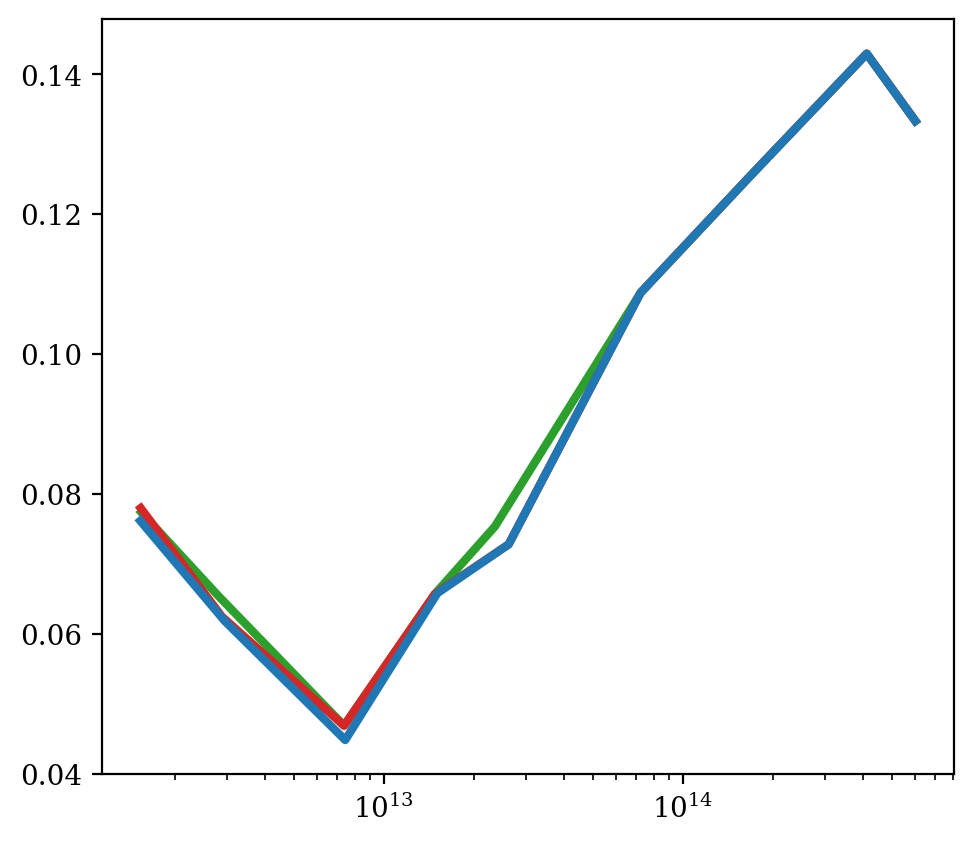

In [23]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale("log")
clean = ~np.isnan(gas_frac_strict['f_gas'][0])
ax.plot(gas_frac_strict['m500c'][0][clean], gas_frac_strict['f_gas'][0][clean], color="C2", lw=3, label='$f_{cont} < 0.001$')

clean = ~np.isnan(gas_frac['f_gas'][0])
ax.plot(gas_frac['m500c'][0][clean], gas_frac['f_gas'][0][clean], color="C3", lw=3, label='$f_{cont} < 0.01$')

clean = ~np.isnan(gas_frac_total['f_gas'][0])
ax.plot(gas_frac_total['m500c'][0][clean], gas_frac_total['f_gas'][0][clean], color="C0", lw=3, label='$f_{cont} < `$')
ax.plot(mtng_gas_frac[:,0], mtng_gas_frac[:,1], color='k', lw=3, label='MTNG')
ax.fill_between( mtng_gas_frac[:,0] , np.interp(mtng_gas_frac[:,0], bottom_bound[:,0], bottom_bound[:,1]),
                np.interp(mtng_gas_frac[:,0], top_bound[:,0], top_bound[:,1]),
                color='gray', alpha=0.2, label="Variation", ec=None)

In [27]:
fgas_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_draws/fgas_draws100_nbins10.npy", allow_pickle=True).item()
mean_fgas, err_fgas = mean_std_without_zeros(fgas_draws['ens_fgas'])
mean_m500c, _ = mean_std_without_zeros(fgas_draws['m500'])

In [28]:
# Popesso et al
m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

# Kugel et al
m500_kugel = np.asarray([13.89, 14.06, 14.23, 14.40, 14.57, 14.74, 14.91])
fgas_kugel = np.asarray([0.083, 0.094, 0.105, 0.115, 0.130, 0.130, 0.139])
err_kugel = np.asarray([0.002, 0.003, 0.005, 0.008, 0.002, 0.002, 0.003])

/tmp/ipykernel_166665/258434034.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


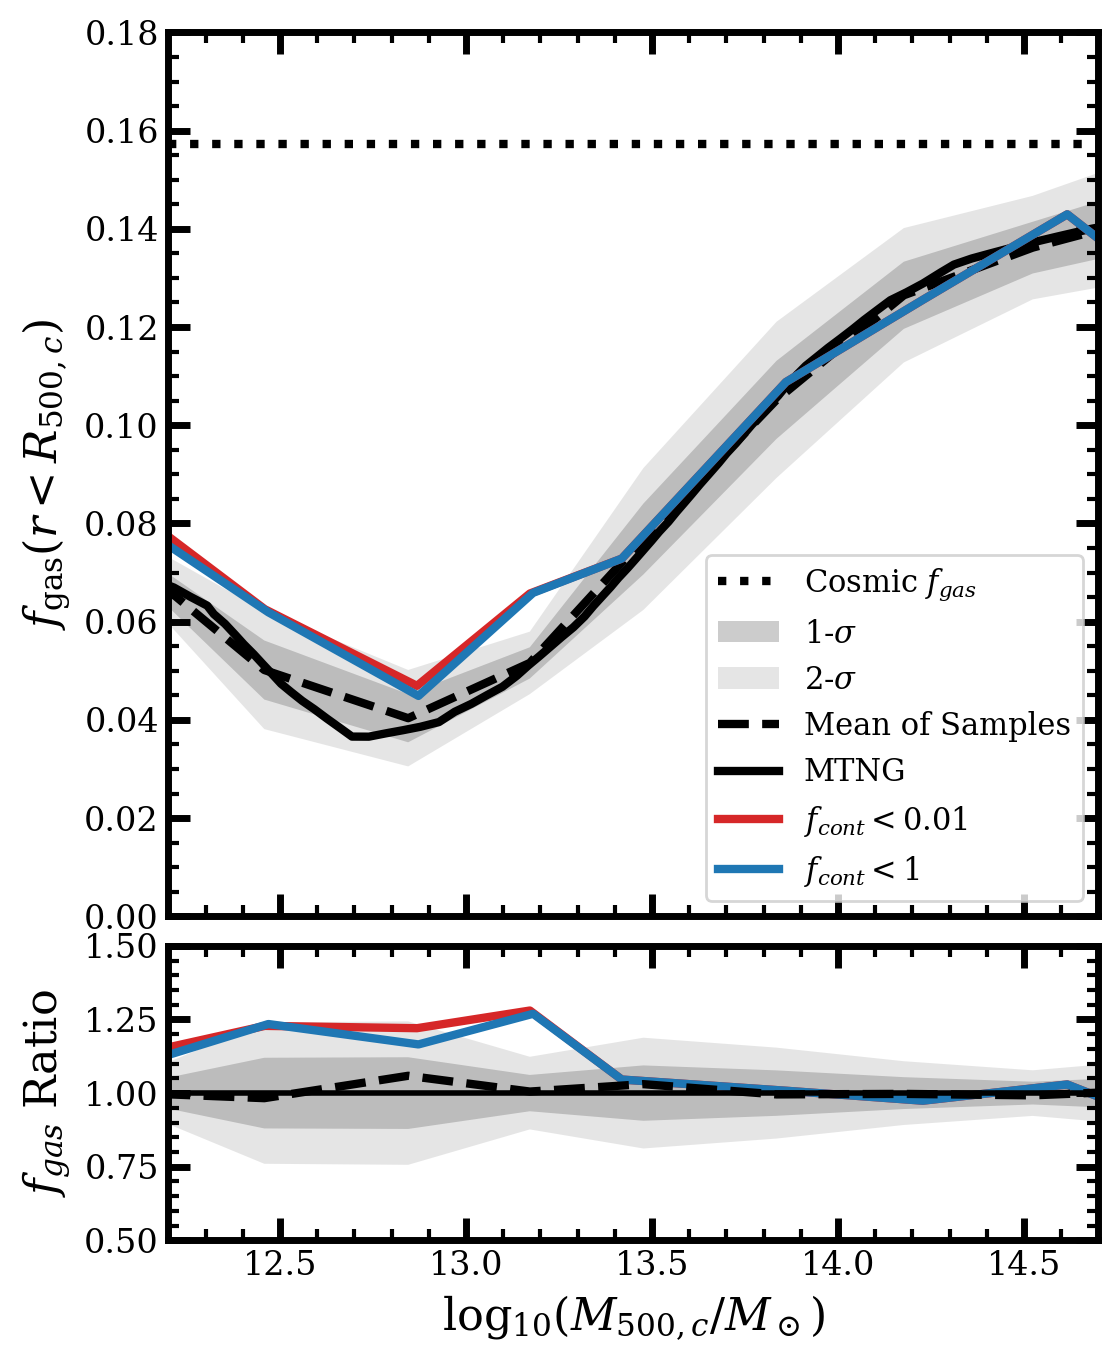

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with two subplots, sharing the x-axis
# height_ratios=[3, 1] makes the top plot 3 times taller than the bottom one
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 8), dpi=200, sharex=True, 
                                 gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})


# ax.errorbar(m500_pp, fgas_pp, yerr=err_pp, fmt='o', color='k', label='Popesso+22')

# --- Main Plot (Top) ---
ax.axhline(0.15733247005503398, color="k", ls=":", lw=3, label='Cosmic $f_{gas}$')
ax.fill_between( np.log10(mean_m500c), mean_fgas - err_fgas,
                mean_fgas + err_fgas,
                color='gray', alpha=0.4, label="$1$-$\sigma$", ec=None)

ax.fill_between(np.log10(mean_m500c), mean_fgas - 2 * err_fgas,
                mean_fgas + 2 * err_fgas,
                color='gray', alpha=0.2, label="$2$-$\sigma$", ec=None)

ax.plot(np.log10(mean_m500c), mean_fgas, color='k', lw=3, label='Mean of Samples', ls='--')
ax.plot(np.log10(mtng_gas_frac[:,0]), mtng_gas_frac[:,1], 
        color="k", lw=3, label='MTNG')
clean_strict = ~np.isnan(gas_frac_strict['f_gas'][0])
# ax.plot(np.log10(gas_frac_strict['m500c'][0][clean_strict]), gas_frac_strict['f_gas'][0][clean_strict], 
#         color="C2", lw=3, label='$f_{cont} < 0.001$')
clean_zoom = ~np.isnan(gas_frac['f_gas'][0])
ax.plot(np.log10(gas_frac['m500c'][0][clean_zoom]), gas_frac['f_gas'][0][clean_zoom], 
        color="C3", lw=3, label='$f_{cont} < 0.01$')
clean_total = ~np.isnan(gas_frac_total['f_gas'][0])
ax.plot(np.log10(gas_frac_total['m500c'][0][clean_total]), gas_frac_total['f_gas'][0][clean_total], 
        color="C0", lw=3, label='$f_{cont} < 1$')

ax.legend(fontsize=11, loc="lower right", ncol=1)
ax.set_ylabel('$f_{\mathrm{gas}}(r<R_{500,c})$', fontsize=16)
ax.set_ylim(0, 0.18)
# --- Residual Plot (Bottom) ---
# Calculate residues
res_strict = gas_frac_strict['f_gas'][0][clean_strict] / np.interp(np.log10(gas_frac_strict['m500c'][0][clean_strict]), 
                                                   np.log10(mtng_gas_frac[:,0]), 
                                                   mtng_gas_frac[:,1])
res_zoom = gas_frac['f_gas'][0][clean_zoom] / np.interp(np.log10(gas_frac['m500c'][0][clean_zoom]), 
                                                   np.log10(mtng_gas_frac[:,0]), 
                                                   mtng_gas_frac[:,1])
res_total = gas_frac_total['f_gas'][0][clean_total] / np.interp(np.log10(gas_frac_total['m500c'][0][clean_total]), 
                                                          np.log10(mtng_gas_frac[:,0]), 
                                                          mtng_gas_frac[:,1])

res_mean = mean_fgas / np.interp(np.log10(mean_m500c), 
                                np.log10(mtng_gas_frac[:,0]), 
                                mtng_gas_frac[:,1])

# ax_res.plot(np.log10(gas_frac_strict['m500c'][0][clean_strict]), res_strict, color="C2", lw=3)
ax_res.plot(np.log10(gas_frac['m500c'][0][clean_zoom]), res_zoom, color="C3", lw=3)
ax_res.plot(np.log10(gas_frac_total['m500c'][0][clean_total]), res_total, color="C0", lw=3)
ax_res.fill_between(np.log10(mean_m500c), 1 - err_fgas / np.mean(fgas_draws['ens_fgas'], axis=0),
                1 + err_fgas / np.mean(fgas_draws['ens_fgas'], axis=0),
                color='gray', alpha=0.4, label="$1-\sigma$", ec=None)

ax_res.fill_between(np.log10(mean_m500c), 1 - 2 * err_fgas / np.mean(fgas_draws['ens_fgas'], axis=0),
                1 + 2 * err_fgas / np.mean(fgas_draws['ens_fgas'], axis=0),
                color='gray', alpha=0.2, label="$2-\sigma$", ec=None)

ax_res.axhline(1, color="k", ls="-", lw=2)
ax_res.plot(np.log10(mean_m500c), res_mean, color='k', lw=3, ls='--')

ax_res.set_ylim(0.5, 1.5)
ax_res.set_xlabel(r"$\log_{10}(M_{500,c}/M_\odot)$", fontsize=16)
ax_res.set_ylabel(r"$f_{gas}$ Ratio", fontsize=16)

# --- Global Formatting ---
ax.set_xlim(12.2, 14.7)

for a in [ax, ax_res]:
    for spine in a.spines.values():
        spine.set_linewidth(2.5)
    
    # Major and minor ticks
    a.tick_params(axis='both', which='major', width=2.5, length=8, labelsize=12, 
                  direction='in', top=True, right=True)
    a.tick_params(axis='both', which='minor', width=1.5, length=4, 
                  direction='in', top=True, right=True)
    a.minorticks_on()

# Remove x-axis tick labels from the top plot to avoid overlap
plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/Notebooks/validation/gas_frac_contamination_comparison.pdf", bbox_inches='tight')
plt.show()